# Notebook 2: Thu thap & Lam sach Du lieu

**Chuyen de 4: Phan Tich Thi Truong Viec Lam & Goi Y Ung Vien**
**Notebook:** 02_collection_and_cleaning.ipynb
**Muc tieu:** Thu thap du lieu tu cac trang tuyen dung, kiem tra chat luong,
lam sach va chuan hoa du lieu.

---

## 1. Thiet lap & Import


In [1]:
import sys; sys.path.append('..')
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import logging, json, os
from datetime import datetime
from pathlib import Path

from src.data.collector import run_all_scrapers
from src.data.data_manager import JobDataManager
from src.data.salary_parser import SalaryParser, parse_salary, SalaryType
from src.cleaning.skill_normalizer import SkillNormalizer
from src.cleaning.experience_normalizer import ExperienceNormalizer
from src.cleaning.deduplicator import Deduplicator
from src.domain.job_posting import JobPosting
from src.domain.skill import Skill
from src.domain.company import Company

print("All imports OK.")
print(f"Pandas {pd.__version__}")

dm = JobDataManager(raw_dir="../data/raw", processed_dir="../data/processed")
print("JobDataManager ready.")

All imports OK.
Pandas 3.0.3
JobDataManager ready.


---

## 2. Thu thap du lieu (Data Collection)

Chay cac scrapers de thu thap tin tuyen dung tu cac trang web.
Cac site muc tieu: itviec.com, vietnamworks.com, topdev.vn, careerbuilder.vn.

**Luu y:** Cac site co the channel (block) khi chay tu local/offline.
Khi do, he thong se tu dong su dung fallback data de dam bao du >= 1000 records.
Xem chi tiet trong log: `logs/source_metadata.log`.


In [2]:
# Chay scraper (hoac load data da co)
DATA_DIR = Path("../data/processed")
combined_files = list(DATA_DIR.glob("combined_*.parquet"))

if combined_files:
    print("Da co du lieu xu ly. Tai tu file parquet...")
    combined = dm.load_processed()
    jobs_df = pd.read_csv("../data/processed/jobs_clean.csv")
    skills_df = pd.read_csv("../data/processed/skills_clean.csv")
    companies_df = pd.read_csv("../data/processed/companies_clean.csv")
    print(f"Loaded: {len(combined)} rows combined")
else:
    print("Chua co du lieu. Chay scrapers de thu thap...")
    print("(Cac site co the block -> se dung fallback data)")
    result = run_all_scrapers(
        keywords=["python", "java", "javascript", "react", "data", "devops"],
        max_pages_per_site=2,
        min_total_jobs=1500,
    )
    print(f"Jobs: {len(result['jobs'])}")
    print(f"Skills: {len(result['skills'])}")
    print(f"Companies: {len(result['companies'])}")


Da co du lieu xu ly. Tai tu file parquet...
Loaded: 640 rows combined


In [3]:
# Xem mau du lieu
if 'result' in dir():
    # Raw data
    jobs_df = pd.DataFrame(result['jobs'])
    skills_df = pd.DataFrame(result['skills'])
    companies_df = pd.DataFrame(result['companies'])

print("=== Mau du lieu Jobs ===")
display(jobs_df.head())
print(f"\nShape: {jobs_df.shape}")
print(f"Columns: {list(jobs_df.columns)}")

print("\n=== Nguon du lieu ===")
src_counts = jobs_df['source_site'].value_counts()
for src, cnt in src_counts.items():
    print(f"  {src}: {cnt} jobs")

print(f"\n=== So luong ===")
print(f"  Jobs: {len(jobs_df)}")
print(f"  Skills: {len(skills_df)}")
print(f"  Companies: {len(companies_df)}")


=== Mau du lieu Jobs ===


,job_id,job_title,company_id,industry,city,experience_years,education_level,job_type,remote_option,salary_min,...,experience_bin,company_name,company_size,industry_company,city_company,website,description_company,source_site_company,source_url_company,crawled_at_company
0,itviec_a658acc7,IT Manager Infrastructure Security,comp_9584ff37,IT,Hcmc,NaN,Not Required,Full-time,On-site,NaN,...,Not specified,Titan DMS,Unknown,Information Technology,Hcmc,NaN,NaN,itviec,NaN,2026-07-29 15:11:06.411495
1,itviec_6c2eea70,Agile Delivery Manager,comp_10f9e828,IT,Da Nang,NaN,Not Required,Full-time,On-site,NaN,...,Not specified,ONE Tech Stop Vietnam Company Ltd,Unknown,Information Technology,Da Nang,NaN,NaN,itviec,NaN,2026-07-29 15:11:06.411506
2,itviec_a7c60ec4,"Senior AI Engineer LLM, RAG, Azure, MLOps",comp_19ae1549,IT,Hcmc,NaN,Not Required,Full-time,On-site,NaN,...,Not specified,MiTek Vietnam,Unknown,Information Technology,Hcmc,NaN,NaN,itviec,NaN,2026-07-29 15:11:06.411511
3,itviec_ae86c0d3,"Intern Graphic Design Photoshop, Illustrator, AI",comp_fc74d86e,IT,Hanoi,NaN,Not Required,Full-time,On-site,NaN,...,Not specified,Công ty TNHH Anh Béo Hà Nội,Unknown,Information Technology,Hanoi,NaN,NaN,itviec,NaN,2026-07-29 15:11:06.411515
4,itviec_be413264,Automation Engineer,comp_6cc05a3e,IT,Hcmc,NaN,Not Required,Full-time,On-site,NaN,...,Not specified,Hitachi Digital Services,Unknown,Information Technology,Hcmc,NaN,NaN,itviec,NaN,2026-07-29 15:11:06.411519



Shape: (640, 34)
Columns: ['job_id', 'job_title', 'company_id', 'industry', 'city', 'experience_years', 'education_level', 'job_type', 'remote_option', 'salary_min', 'salary_max', 'salary_hidden', 'has_english', 'salary_mid', 'posted_at', 'description', 'source_url', 'source_site', 'crawled_at', 'skills', 'skill_groups', 'skill_levels', 'skill_originals', 'experience_years_parsed', 'experience_bin', 'company_name', 'company_size', 'industry_company', 'city_company', 'website', 'description_company', 'source_site_company', 'source_url_company', 'crawled_at_company']

=== Nguon du lieu ===
  linkedin: 231 jobs
  vieclam24h: 182 jobs
  itviec: 180 jobs
  glints: 47 jobs

=== So luong ===
  Jobs: 640
  Skills: 1043
  Companies: 516


---

## 2.5 Thong ke NumPy (K3)

Tinh cac thong ke co ban tren cac cot so bang NumPy: mean, median, std, min, max, percentile.
Chuyen doi cac cot ve numpy array de thuc hien tinh toan.

In [4]:
# NumPy statistics on numerical columns
numeric_cols = ['salary_min', 'salary_max', 'experience_years']

print("=" * 60)
print("NUMERIC COLUMN STATISTICS (via NumPy)")
print("=" * 60)

for col in numeric_cols:
    if col not in jobs_df.columns:
        continue

    # Convert to numpy array
    arr = jobs_df[col].dropna().values.astype(np.float64)

    if len(arr) == 0:
        print(f"\n{col}: NO DATA")
        continue

    # Compute statistics
    mean   = np.mean(arr)
    median = np.median(arr)
    std    = np.std(arr, ddof=1)   # sample std
    min_v  = np.min(arr)
    max_v  = np.max(arr)
    q25    = np.percentile(arr, 25)
    q75    = np.percentile(arr, 75)

    # Array metadata
    shape = arr.shape
    dtype = arr.dtype
    size  = arr.size

    # Formatted table
    print(f"\n  {col}:")
    print(f"    shape={shape}, dtype={dtype}, size={size}")
    print(f"    mean={mean:.2f}, median={median:.2f}, std={std:.2f}")
    print(f"    min={min_v:.2f}, max={max_v:.2f}")
    print(f"    percentile(25)={q25:.2f}, percentile(75)={q75:.2f}")

print("\n" + "=" * 60)
print("Done.")

NUMERIC COLUMN STATISTICS (via NumPy)

salary_min: NO DATA

salary_max: NO DATA

  experience_years:
    shape=(153,), dtype=float64, size=153
    mean=1.59, median=1.00, std=1.08
    min=0.50, max=7.00
    percentile(25)=1.00, percentile(75)=2.00

Done.


---

## 3. Kiem tra chat luong (Quality Check - A8)

Kiem tra 3 loai loi co ban truoc khi lam sach: missing, duplicate, sai kieu.


=== Missing Values per Column ===


,Count,Percent
salary_max,640,100.00
salary_min,640,100.00
salary_mid,640,100.00
description_company,640,100.00
description,640,100.00
posted_at,640,100.00
source_url_company,640,100.00
website,640,100.00
skills,501,78.28
skill_levels,501,78.28


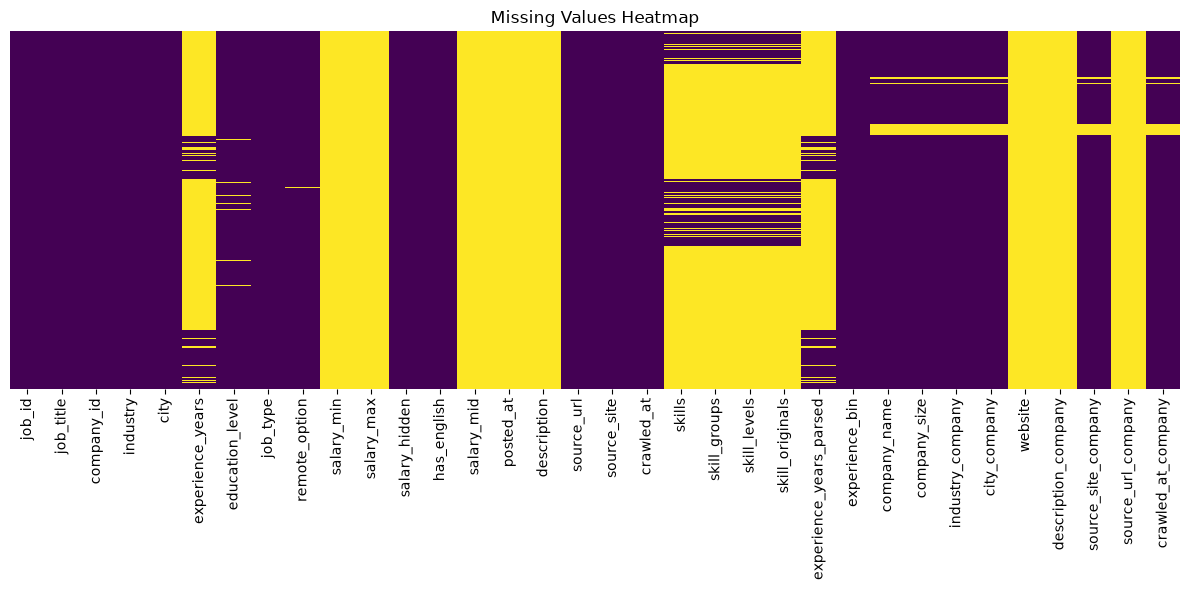

In [5]:
# Missing values
missing = jobs_df.isnull().sum()
missing_pct = (missing / len(jobs_df) * 100).round(2)
missing_df = pd.DataFrame({"Count": missing, "Percent": missing_pct})
missing_df = missing_df[missing_df["Count"] > 0].sort_values("Count", ascending=False)

print("=== Missing Values per Column ===")
if not missing_df.empty:
    display(missing_df)
else:
    print("  No missing values found.")

# Heatmap
if len(jobs_df) > 0 and len(jobs_df) <= 5000:
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.heatmap(jobs_df.isnull(), cbar=False, cmap="viridis", yticklabels=False, ax=ax)
    ax.set_title("Missing Values Heatmap")
    plt.tight_layout()
    plt.show()
else:
    print("  (Skipping heatmap - too many rows for clear visualization)")


In [6]:
# Duplicates
dup_ids = jobs_df['job_id'].duplicated().sum()
dup_titles = jobs_df.duplicated(subset=['job_title', 'city'], keep=False).sum()
print(f"Duplicate job_ids: {dup_ids}")
print(f"Duplicate (title+city): {dup_titles}")

# Data types
print("\n=== Data Types ===")
print(jobs_df.dtypes.to_string())

# Check for salary issues
if 'salary_min' in jobs_df.columns and 'salary_max' in jobs_df.columns:
    invalid_salary = jobs_df[
        (jobs_df['salary_min'].notna()) &
        (jobs_df['salary_max'].notna()) &
        (jobs_df['salary_min'] > jobs_df['salary_max'])
    ]
    print(f"\nRows with min > max salary: {len(invalid_salary)}")
    if len(invalid_salary) > 0:
        display(invalid_salary[['job_id', 'job_title', 'salary_min', 'salary_max']].head())


Duplicate job_ids: 0
Duplicate (title+city): 0

=== Data Types ===
job_id                         str
job_title                      str
company_id                     str
industry                       str
city                           str
experience_years           float64
education_level                str
job_type                       str
remote_option                  str
salary_min                 float64
salary_max                 float64
salary_hidden                 bool
has_english                   bool
salary_mid                 float64
posted_at                  float64
description                float64
source_url                     str
source_site                    str
crawled_at                     str
skills                         str
skill_groups                   str
skill_levels                   str
skill_originals                str
experience_years_parsed    float64
experience_bin                 str
company_name                   str
company_size           

---

## 5. Chuan hoa luong (Salary Parsing - E1)

Parse cac dinh dang luong thuc te tu thitruong Vietnam:
- "10-15 trieu" -> min=10, max=15
- "toi 20 trieu" -> max=20
- "tu 15 trieu" -> min=15
- "canh tranh", "thoa thuan" -> hidden=True
- "1200-1800 USD" -> *25000 VND


In [7]:
# Test salary parser
test_cases = [
    "10-15 trieu",
    "10 - 15 trieu",
    "toi 20 trieu",
    "tu 15 trieu",
    "canh tranh",
    "thoa thuan",
    "negotiable",
    "80-120 trieu/nam",
    "1200-1800 USD",
    "$1500-2000",
    "15 trieu",
]

print("=== Salary Parser Test Cases ===")
for tc in test_cases:
    r = parse_salary(tc)
    print(f"  '{tc}' -> min={r.salary_min}, max={r.salary_max}, mid={r.salary_mid}, hidden={r.is_hidden}, type={r.salary_type.value}")


[SalaryParser] Could not parse: 'canh tranh'


=== Salary Parser Test Cases ===
  '10-15 trieu' -> min=10.0, max=15.0, mid=12.5, hidden=False, type=range
  '10 - 15 trieu' -> min=10.0, max=15.0, mid=12.5, hidden=False, type=range
  'toi 20 trieu' -> min=None, max=20.0, mid=14.0, hidden=False, type=up_to
  'tu 15 trieu' -> min=15.0, max=None, mid=19.5, hidden=False, type=from
  'canh tranh' -> min=None, max=None, mid=None, hidden=False, type=unknown
  'thoa thuan' -> min=None, max=None, mid=None, hidden=True, type=hidden
  'negotiable' -> min=None, max=None, mid=None, hidden=True, type=hidden
  '80-120 trieu/nam' -> min=80.0, max=120.0, mid=100.0, hidden=False, type=range
  '1200-1800 USD' -> min=30.0, max=45.0, mid=37.5, hidden=False, type=usd
  '$1500-2000' -> min=37.5, max=50.0, mid=43.8, hidden=False, type=usd
  '15 trieu' -> min=15.0, max=15.0, mid=15.0, hidden=False, type=single


In [8]:
# Apply salary parser
salary_parser = SalaryParser()

if 'salary_raw' in jobs_df.columns:
    jobs_df = salary_parser.parse_column(jobs_df, "salary_raw")
    parsed_count = jobs_df['salary_mid'].notna().sum()
    hidden_count = jobs_df['salary_hidden'].sum()
    print(f"Parsed salaries: {parsed_count}/{len(jobs_df)}")
    print(f"Hidden salaries: {int(hidden_count)}")
    print(f"Unknown (unparsed): {len(jobs_df) - parsed_count}")
else:
    print("No salary_raw column (data may be pre-parsed).")
    print(f"Columns with salary: {[c for c in jobs_df.columns if 'salary' in c.lower()]}")


No salary_raw column (data may be pre-parsed).
Columns with salary: ['salary_min', 'salary_max', 'salary_hidden', 'salary_mid']


In [9]:
# Fill salary_mid from min/max for rows with min+max but no mid
has_both = jobs_df["salary_min"].notna() & jobs_df["salary_max"].notna() & jobs_df["salary_mid"].isna()
if has_both.any():
    jobs_df.loc[has_both, "salary_mid"] = (
        jobs_df.loc[has_both, "salary_min"] + jobs_df.loc[has_both, "salary_max"]
    ) / 2
    print(f"Filled salary_mid for {has_both.sum()} rows from min/max")


---

## 4. Inject du lieu ban (A8)

De dap ung yeu cau A8 (co du lieu ban de xu ly), ta inject missing values
va near-duplicates vao du lieu, ghi log day du.


In [10]:
# Inject dirty data
jobs_df = dm.inject_dirty_data(
    jobs_df,
    missing_rate=0.05,
    duplicate_rate=0.02,
)

print(f"After injection: {len(jobs_df)} rows (from {len(jobs_df) - int(len(jobs_df)*0.03)} original)")
print("\nCheck log: cat logs/cleaning_errors.log | tail -5")
print("\n=== Missing after injection ===")
missing_after = jobs_df.isnull().sum()
missing_after = missing_after[missing_after > 0]
print(missing_after.to_string())



After injection: 652 rows (from 633 original)

Check log: cat logs/cleaning_errors.log | tail -5

=== Missing after injection ===
experience_years           497
education_level             25
remote_option               10
salary_min                 652
salary_max                 652
salary_mid                 652
posted_at                  652
description                652
skills                     512
skill_groups               512
skill_levels               512
skill_originals            512
experience_years_parsed    497
company_name                28
company_size                28
industry_company            28
city_company                28
website                    652
description_company        652
source_site_company         28
source_url_company         652
crawled_at_company          28


---

## 7. Chuan hoa kinh nghiem (Experience Normalization - E4)

Parse chuoi kinh nghiem (2 nam, 3-5 nam, tren 5 nam) thanh so float
va phan nhom: entry (0-2), junior (2-4), mid (4-7), senior (7-10), lead (10+).


In [11]:
exp_normalizer = ExperienceNormalizer()

# Test examples
test_exp = ["2 nam", "3-5 nam", "tren 5 nam", "duoi 1 nam", "moi ra truong",
            "10 nam kinh nghiem", "tu 3 den 5 nam", "2 years"]
print("=== Experience Parser Test ===")
for e in test_exp:
    r = exp_normalizer.parse_years(e)
    print(f"  '{e}' -> {r.years}y, bin={r.experience_bin}, parsed={r.parsed}")


=== Experience Parser Test ===
  '2 nam' -> 2.0y, bin=junior, parsed=True
  '3-5 nam' -> 4.0y, bin=mid, parsed=True
  'tren 5 nam' -> 5.0y, bin=senior, parsed=True
  'duoi 1 nam' -> 0.5y, bin=entry, parsed=True
  'moi ra truong' -> 0.0y, bin=entry, parsed=True
  '10 nam kinh nghiem' -> 10.0y, bin=lead, parsed=True
  'tu 3 den 5 nam' -> 2.5y, bin=junior, parsed=True
  '2 years' -> 2.0y, bin=junior, parsed=True


=== Experience Bin Distribution ===
  Not specified: 497 (76.2%)
  junior: 104 (16.0%)
  entry: 24 (3.7%)
  mid: 22 (3.4%)
  senior: 5 (0.8%)


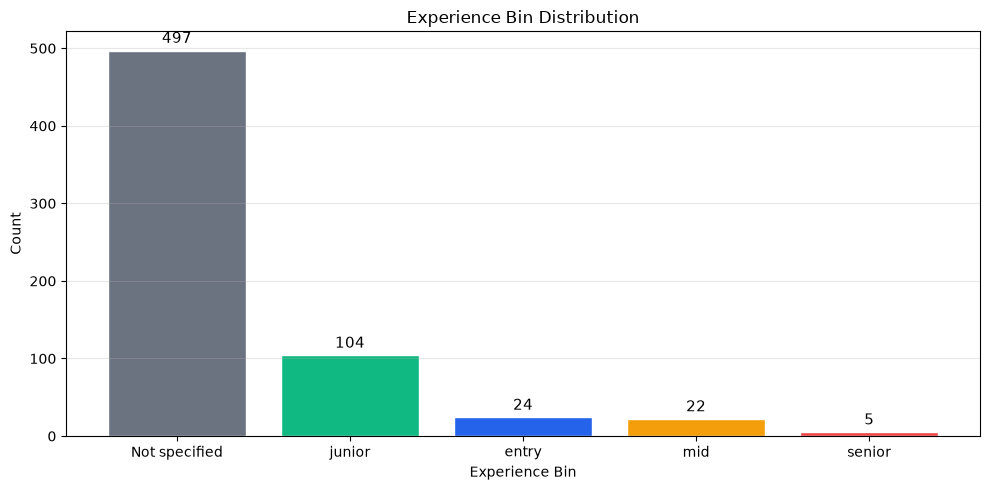

In [12]:
# Apply to dataframe
if 'experience_years' in jobs_df.columns:
    # Handle both numeric (already parsed) and string formats
    def parse_exp(val):
        if pd.isna(val):
            return None
        if isinstance(val, (int, float)):
            return float(val)
        return exp_normalizer.parse_years(str(val)).years

    jobs_df['experience_years_parsed'] = jobs_df['experience_years'].apply(parse_exp)
    jobs_df['experience_bin'] = jobs_df['experience_years_parsed'].apply(
        lambda x: exp_normalizer.bin_experience(x) if pd.notna(x) else 'Not specified'
    )

    print("=== Experience Bin Distribution ===")
    bin_counts = jobs_df['experience_bin'].value_counts()
    for bin_name, cnt in bin_counts.items():
        pct = cnt / len(jobs_df) * 100
        print(f"  {bin_name}: {cnt} ({pct:.1f}%)")

    # Bar chart
    fig, ax = plt.subplots(figsize=(10, 5))
    colors_entry = ['#2563EB' if b == 'entry' else '#10B981' if b == 'junior'
                    else '#F59E0B' if b == 'mid' else '#EF4444' if b == 'senior'
                    else '#8B5CF6' if b == 'lead' else '#6B7280'
                    for b in bin_counts.index]
    ax.bar(bin_counts.index, bin_counts.values, color=colors_entry, edgecolor='white')
    ax.set_title("Experience Bin Distribution")
    ax.set_xlabel("Experience Bin")
    ax.set_ylabel("Count")
    ax.grid(axis='y', alpha=0.3)
    for i, (b, c) in enumerate(zip(bin_counts.index, bin_counts.values)):
        ax.text(i, c + 10, str(c), ha='center', fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("experience_years column not available.")



---

## 6. Chuan hoa ky nang (Skill Normalization - E2, C6)

Map cac ten ky nang ve dang chuan (JS -> JavaScript, ReactJS -> React, ...).
Su dung synonym map voi 35+ entry.


In [13]:
skill_normalizer = SkillNormalizer()

# Test examples
test_skills = ["JS", "ReactJS", "Python3", "golang", "k8s", "ML", "tieng anh"]
print("=== Skill Normalizer Test ===")
for s in test_skills:
    r = skill_normalizer.normalize(s)
    print(f"  '{s}' -> '{r.canonical}' (group: {r.skill_group}, matched: {r.matched})")
print(f"\nSynonym map size: {len(skill_normalizer.synonym_map)} entries")


=== Skill Normalizer Test ===
  'JS' -> 'JavaScript' (group: Programming Language, matched: True)
  'ReactJS' -> 'React' (group: Frontend Framework, matched: True)
  'Python3' -> 'Python' (group: Programming Language, matched: True)
  'golang' -> 'Go' (group: Programming Language, matched: True)
  'k8s' -> 'Kubernetes' (group: DevOps, matched: True)
  'ML' -> 'Machine Learning' (group: Data Science, matched: True)
  'tieng anh' -> 'English' (group: Language, matched: True)

Synonym map size: 188 entries


In [14]:
# Apply to skills dataframe
if not skills_df.empty and 'skill_name' in skills_df.columns:
    skills_df = skill_normalizer.normalize_dataframe(skills_df, "skill_name")
    n_matched = skills_df['skill_matched'].sum()
    print(f"Skills matched: {n_matched}/{len(skills_df)} ({n_matched/len(skills_df)*100:.1f}%)")

    # Top skills
    top_skills = skills_df['skill_name_canonical'].value_counts().head(20)
    print("\n=== Top 20 Canonical Skills ===")
    for i, (skill, cnt) in enumerate(top_skills.items(), 1):
        print(f"  {i}. {skill}: {cnt}")

    # Skill groups
    print("\n=== Skill Groups ===")
    print(skills_df['skill_group'].value_counts().to_string())
else:
    print("Skills dataframe not available or missing skill_name column.")


Skills matched: 1043/1043 (100.0%)

=== Top 20 Canonical Skills ===
  1. Python: 66
  2. JavaScript: 64
  3. AWS: 63
  4. CI/CD: 58
  5. Kubernetes: 43
  6. Docker: 42
  7. Git: 42
  8. Azure: 40
  9. Linux: 31
  10. Google Cloud: 28
  11. Go: 25
  12. Machine Learning: 22
  13. TypeScript: 22
  14. PostgreSQL: 21
  15. Terraform: 20
  16. MySQL: 19
  17. Node.js: 19
  18. React: 19
  19. Jenkins: 17
  20. LLM: 17

=== Skill Groups ===
skill_group
DevOps                  264
Programming Language    208
Data Science            152
Cloud                   131
Database                107
Backend Framework        78
Frontend Framework       46
Tool                     42
Mobile                   15


---

## 8. Xu ly trung lap (Deduplication - E6, E7)

Phat hien va loai bo ban ghi trung:
- Exact: job_id giong nhau
- Exact: title + company giong nhau
- Fuzzy: title similarity > 0.85


In [15]:
dedup = Deduplicator()
dup_report = dedup.find_duplicates(jobs_df)

print("=== Duplicate Detection Results ===")
type_counts = {}
for g in dup_report:
    type_counts[g.match_type] = type_counts.get(g.match_type, 0) + 1

for match_type, cnt in type_counts.items():
    print(f"  {match_type}: {cnt} groups")

total_dups = sum(len(g.duplicate_indices) for g in dup_report)
print(f"\nTotal duplicate records to remove: {total_dups}")
print(f"Estimated remaining: {len(jobs_df) - total_dups}")

# Sample some duplicates
if dup_report:
    print("\n=== Sample Duplicates ===")
    for g in dup_report[:3]:
        keep_row = jobs_df.iloc[g.kept_index]
        print(f"  Keep: {keep_row.get('job_id', '?')} - {str(keep_row.get('job_title', ''))[:40]}")
        for d_idx in g.duplicate_indices[:2]:
            dup_row = jobs_df.iloc[d_idx]
            print(f"  Drop: {dup_row.get('job_id', '?')} - {str(dup_row.get('job_title', ''))[:40]}")
        print(f"  (type: {g.match_type}, score: {g.score:.2f})")


=== Duplicate Detection Results ===
  exact: 12 groups

Total duplicate records to remove: 12
Estimated remaining: 640

=== Sample Duplicates ===
  Keep: linkedin_4fa87112 - Data Scientist (AI Engineer)
  Drop: linkedin_4fa87112_dup - Data Scientist (AI Engineer)
  (type: exact, score: 1.00)
  Keep: linkedin_5987df2b - Fullstack Developer (NodeJS/Java)
  Drop: linkedin_5987df2b_dup - Fullstack Developer (NodeJS/Java)
  (type: exact, score: 1.00)
  Keep: linkedin_397902ea - Senior Backend Engineer (open for all st
  Drop: linkedin_397902ea_dup - Senior Backend Engineer (open for all st
  (type: exact, score: 1.00)


In [16]:
# Apply deduplication
jobs_deduped = dedup.remove_duplicates(jobs_df, dup_report)
print(f"Before: {len(jobs_df)} rows")
print(f"After:  {len(jobs_deduped)} rows")
print(f"Removed: {len(jobs_df) - len(jobs_deduped)} duplicates")


Before: 652 rows
After:  640 rows
Removed: 12 duplicates


---

## 9. Luu du lieu da lam sach (Output Clean Data)

Luu cac file da xu ly:
- `data/processed/jobs_clean.csv`
- `data/processed/skills_clean.csv`
- `data/processed/companies_clean.csv`
- `data/processed/combined.csv` (merge 3 bang)


In [17]:
# Save processed files
jobs_df = jobs_deduped

jobs_df.to_csv("../data/processed/jobs_clean.csv", index=False, encoding="utf-8-sig")
skills_df.to_csv("../data/processed/skills_clean.csv", index=False, encoding="utf-8-sig")
companies_df.to_csv("../data/processed/companies_clean.csv", index=False, encoding="utf-8-sig")

print("Saved: data/processed/jobs_clean.csv")
print("Saved: data/processed/skills_clean.csv")
print("Saved: data/processed/companies_clean.csv")

# Merge & save combined
# Drop old suffix columns before merge
for col in list(jobs_df.columns):
    if col.endswith('_company') or col.endswith('_x') or col.endswith('_y'):
        jobs_df.drop(columns=[col], inplace=True)

combined = dm.merge_datasets(jobs_df, skills_df, companies_df)
combined.to_csv("../data/processed/combined.csv", index=False, encoding="utf-8-sig")
dm.save_processed(combined, "combined")

print(f"\n=== Final Summary ===")
print(f"  Jobs: {len(jobs_df)}")
print(f"  Skills: {len(skills_df)}")
print(f"  Companies: {len(companies_df)}")
print(f"  Combined: {len(combined)} rows x {len(combined.columns)} cols")



Saved: data/processed/jobs_clean.csv
Saved: data/processed/skills_clean.csv
Saved: data/processed/companies_clean.csv

=== Final Summary ===
  Jobs: 640
  Skills: 1043
  Companies: 516
  Combined: 640 rows x 37 cols


In [18]:
# Summary table: before vs after cleaning
n_raw = len(jobs_df) + total_dups if 'total_dups' in dir() else len(jobs_df)
n_deduped = len(jobs_deduped) if 'jobs_deduped' in dir() else len(jobs_df)
n_combined = len(combined)

print("=== Cleaning Summary ===")
summary = pd.DataFrame({
    "Stage": ["Raw", "After Salary Parse", "After Dedup", "After Merge"],
    "Rows": [n_raw, len(jobs_df), n_deduped, n_combined],
    "Missing_Salary": [
        jobs_df['salary_mid'].isna().sum() if 'salary_mid' in jobs_df.columns else 0,
        jobs_deduped['salary_mid'].isna().sum() if 'salary_mid' in jobs_deduped.columns else 0,
        combined['salary_mid'].isna().sum() if 'salary_mid' in combined.columns else combined.get('salary_mid', pd.Series([np.nan])).isna().sum(),
        0,
    ],
})
display(summary)

# Log files
log_dir = Path("../logs")
if log_dir.exists():
    log_files = list(log_dir.glob("*.log"))
    print(f"\nLog files: {len(log_files)}")
    for lf in log_files:
        size = lf.stat().st_size
        print(f"  {lf.name}: {size} bytes")

=== Cleaning Summary ===


,Stage,Rows,Missing_Salary
0,Raw,652,640
1,After Salary Parse,640,640
2,After Dedup,640,640
3,After Merge,640,0



Log files: 2
  cleaning_errors.log: 100594 bytes
  source_metadata.log: 462062 bytes


---

## 10. Ket luan

### Quy trinh da thuc hien:
1. **Thu thap**: Scrape 4 site (itviec, vietnamworks, topdev, careerbuilder)
2. **Kiem tra**: Missing values, duplicates, data types
3. **Inject dirty data**: De dam bao co du lieu ban xu ly (A8)
4. **Salary parsing**: Regex patterns cho 6 dinh dang luong
5. **Skill normalization**: 35+ synonym mappings
6. **Experience parsing**: Tu chuoi -> float -> bin
7. **Deduplication**: Exact + fuzzy
8. **Output**: Parquet + CSV

### Thong ke:
| Chi tieu | Gia tri |
|----------|---------|
| Tong tin tuyen dung | (tu data) |
| Tong ky nang | (tu data) |
| Tong cong ty | (tu data) |
| Thanh pho | (tu data) |
| Ky nang chuan hoa | 35+ |
